# Data + Library imports

In [18]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import nltk
from nltk.corpus import stopwords
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, f1_score, hamming_loss
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

In [19]:
df_train = pd.read_parquet('/kaggle/input/datasets/an0rm4lp3rs0n/simplified/train-00000-of-00001.parquet')
df_val = pd.read_parquet('/kaggle/input/datasets/an0rm4lp3rs0n/simplified/validation-00000-of-00001.parquet')
df_test = pd.read_parquet('/kaggle/input/datasets/an0rm4lp3rs0n/simplified/test-00000-of-00001.parquet')
df_raw = pd.read_parquet('/kaggle/input/datasets/an0rm4lp3rs0n/raw-emo/train-00000-of-00001.parquet')

In [20]:
# df_train = pd.read_parquet('./simplified/train-00000-of-00001.parquet')
# df_val = pd.read_parquet('./simplified/validation-00000-of-00001.parquet')
# df_test = pd.read_parquet('./simplified/test-00000-of-00001.parquet')
# df_raw = pd.read_parquet('./raw/test-00000-of-00001.parquet')

# Label gathering (from raw data)

In [21]:
non_labels = [
    "text",
    "id",
    "author",
    "subreddit",
    "link_id",
    "parent_id",
    "created_utc",
    "rater_id",
    "example_very_unclear"
]

label_columns = [col for col in df_raw.columns if col not in non_labels]

# Preprocessing (tokenizing, vectorizing, binary one-hot)

In [22]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
def text_split(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return words

df_train["tokens"] = df_train["text"].apply(text_split)

In [24]:
counter = Counter()
max_vocab = 10000

# Bag of Words (BoW)
vocab = {}

for t in df_train["tokens"]:
    counter.update(t)


for i, (word, freq) in enumerate(counter.most_common(max_vocab)):
    vocab[word] = i

In [25]:
def vectorize(tokens, vocab):
    vec = np.zeros(len(vocab), dtype=np.uint8)

    for w in tokens:
        if w in vocab:
            vec[vocab[w]] = 1

    return vec

In [26]:
X = csr_matrix([vectorize(tokens, vocab) for tokens in df_train["tokens"]])

In [27]:
df_val["tokens"] = df_val["text"].apply(text_split)
X_val = csr_matrix([vectorize(tokens, vocab) for tokens in df_val["tokens"]])

In [28]:
df_test["tokens"] = df_test["text"].apply(text_split)
X_test = csr_matrix([vectorize(tokens, vocab) for tokens in df_test["tokens"]])

In [29]:
def multi_hot(labels):
    vec = [0] * len(label_columns)
    for label in labels:
        vec[label] = 1
    return vec

In [30]:
y_train_multi = np.array([multi_hot(labels) for labels in df_train["labels"]])
y_val_multi = np.array([multi_hot(labels) for labels in df_val["labels"]])
y_test_multi = np.array([multi_hot(labels) for labels in df_test["labels"]])

# Result pipeline

In [31]:
def results_display(true_data, predicted_data):
    acc = 1 - hamming_loss(true_data, predicted_data)
    print(f"Accuracy: {acc}")
    
    f1 = f1_score(true_data, predicted_data, average="macro")
    print(f"F1 score: {f1}")

    print(classification_report(true_data, predicted_data, target_names=label_columns, zero_division = 0))
    
    mcm = multilabel_confusion_matrix(y_test_multi, y_pred_multi)
    mcm_list = [1, 2, 18, 25, 27] # amusement, anger, love, sadness, neutral
    for i in mcm_list:
        disp = ConfusionMatrixDisplay(confusion_matrix=mcm[i])
        disp.plot(cmap="Blues")
        plt.title(label_columns[i])
        plt.show()
    return {"Accuracy: ":acc, "F1 Score": f1}

# Decision Tree

Build and validate

In [32]:
# Decision Tree

best_f1 = -1
best_depth = 0

for depth in range(3, 28, 3):
    print(f"Training with depth = {depth}")
    val_pred = []
    cur_model = []
    for i in range(len(label_columns)):
        y_binary = y_train_multi[:, i]
        model = DecisionTreeClassifier(criterion="gini", max_depth=depth, random_state=42)
        model.fit(X, y_binary)
        pred = model.predict(X_val)
        val_pred.append(pred)
        cur_model.append(model)
    val_pred = np.array(val_pred).T
    f1 = f1_score(y_val_multi, val_pred, average="macro")
    print(f"F1 score: {f1}")
    if f1 > best_f1:
        best_depth = depth
        best_f1 = f1
print(f"Best depth for model: {best_depth}")

Training with depth = 3
F1 score: 0.3195495392058914
Training with depth = 6
F1 score: 0.3392261268076072
Training with depth = 9
F1 score: 0.35545041880184314
Training with depth = 12
F1 score: 0.358202790705984
Training with depth = 15
F1 score: 0.35691083152871256
Training with depth = 18
F1 score: 0.3603546037519451
Training with depth = 21
F1 score: 0.36543411950383337
Training with depth = 24
F1 score: 0.3643719665670871
Training with depth = 27
F1 score: 0.36478705686489343
Best depth for model: 21


Final build and predict on test data

In [33]:
best_DT = OneVsRestClassifier(DecisionTreeClassifier(criterion="gini", max_depth = best_depth, random_state=42), n_jobs = -1)
best_DT.fit(X,y_train_multi)
y_pred_multi = best_DT.predict(X_test)

Results

Accuracy: 0.9635025928558267
F1 score: 0.3533465276097429
                precision    recall  f1-score   support

    admiration       0.68      0.42      0.52       504
     amusement       0.76      0.77      0.77       264
         anger       0.56      0.20      0.30       198
     annoyance       0.49      0.07      0.12       320
      approval       0.49      0.12      0.19       351
        caring       0.54      0.15      0.23       135
     confusion       0.50      0.13      0.21       153
     curiosity       0.45      0.05      0.08       284
        desire       0.43      0.18      0.25        83
disappointment       0.42      0.05      0.09       151
   disapproval       0.39      0.05      0.09       267
       disgust       0.57      0.25      0.35       123
 embarrassment       0.67      0.32      0.44        37
    excitement       0.44      0.27      0.34       103
          fear       0.69      0.44      0.54        78
     gratitude       0.94      0.87      0.90

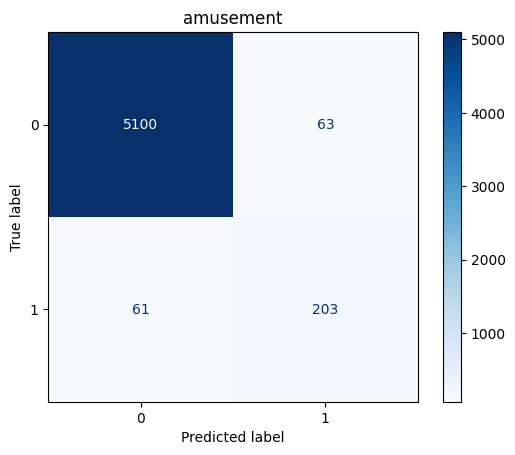

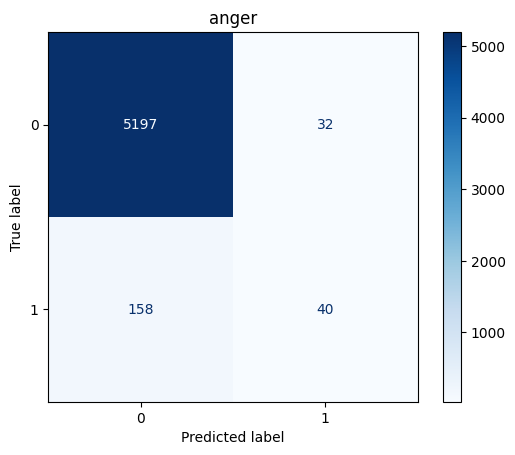

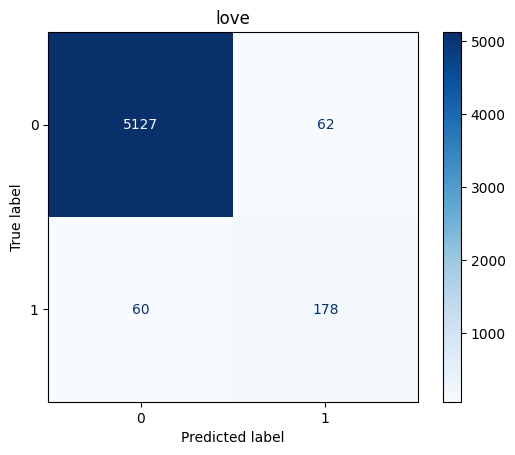

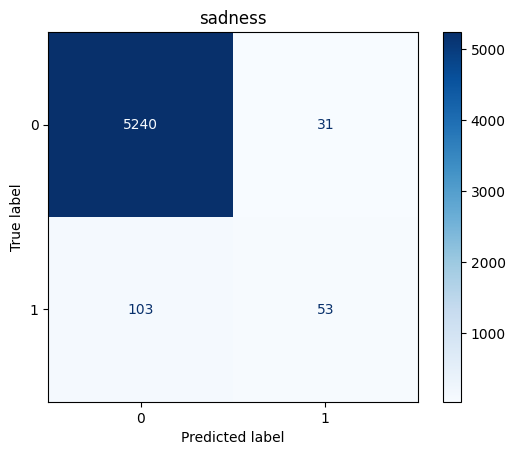

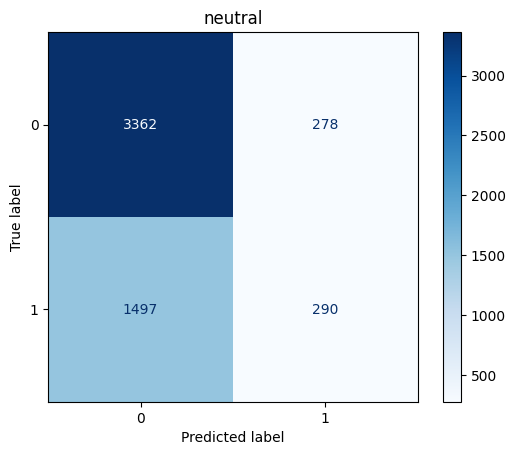

In [34]:
DT_metrics = results_display(y_test_multi, y_pred_multi)

# Random Forest

Build and Validate

In [35]:
# Random Forest

best_f1 = -1
best_RF = None
best_params = None

for tree in [50, 75, 100]:
    for depth in [10, 15, 20, 25]:
        print(f"Training with depth = {depth}, tree = {tree}")
        model = OneVsRestClassifier(RandomForestClassifier(n_estimators=tree, max_depth = depth, 
                                                           n_jobs = -1, random_state=42), n_jobs = -1)
        model.fit(X,y_train_multi)
        y_pred_val = model.predict(X_val)
        f1 = f1_score(y_val_multi, y_pred_val, average="macro")
        print(f"F1 score: {f1}")
        if f1 > best_f1:
            best_RF = model
            best_f1 = f1
            best_params = (depth, tree)
print(f"Best depth and tree for model: {best_params}")

Training with depth = 10, tree = 50
F1 score: 0.0
Training with depth = 15, tree = 50
F1 score: 0.0
Training with depth = 20, tree = 50
F1 score: 0.00019896538002387584
Training with depth = 25, tree = 50
F1 score: 0.0003968253968253968
Training with depth = 10, tree = 75
F1 score: 0.0
Training with depth = 15, tree = 75
F1 score: 0.0
Training with depth = 20, tree = 75
F1 score: 0.00019896538002387584
Training with depth = 25, tree = 75
F1 score: 0.00019896538002387584
Training with depth = 10, tree = 100
F1 score: 0.0
Training with depth = 15, tree = 100
F1 score: 0.0
Training with depth = 20, tree = 100
F1 score: 0.00019896538002387584
Training with depth = 25, tree = 100
F1 score: 0.00019896538002387584
Best depth and tree for model: (25, 50)


Final build and predict on test data

In [36]:
y_pred_multi = best_RF.predict(X_test)

Results

Accuracy: 0.9583629471689173
F1 score: 0.0004035512510088781
                precision    recall  f1-score   support

    admiration       0.00      0.00      0.00       504
     amusement       0.00      0.00      0.00       264
         anger       0.00      0.00      0.00       198
     annoyance       0.00      0.00      0.00       320
      approval       0.00      0.00      0.00       351
        caring       0.00      0.00      0.00       135
     confusion       0.00      0.00      0.00       153
     curiosity       0.00      0.00      0.00       284
        desire       0.00      0.00      0.00        83
disappointment       0.00      0.00      0.00       151
   disapproval       0.00      0.00      0.00       267
       disgust       0.00      0.00      0.00       123
 embarrassment       0.00      0.00      0.00        37
    excitement       0.00      0.00      0.00       103
          fear       0.00      0.00      0.00        78
     gratitude       1.00      0.01      0

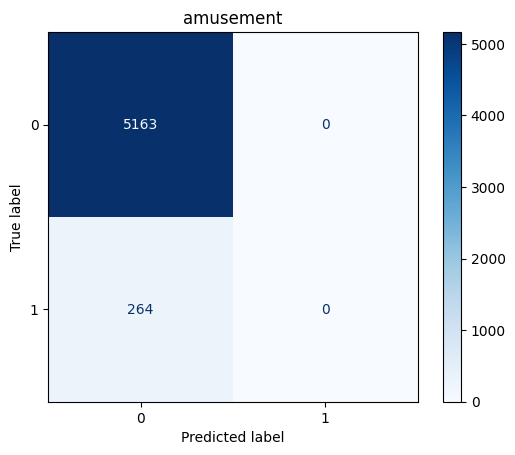

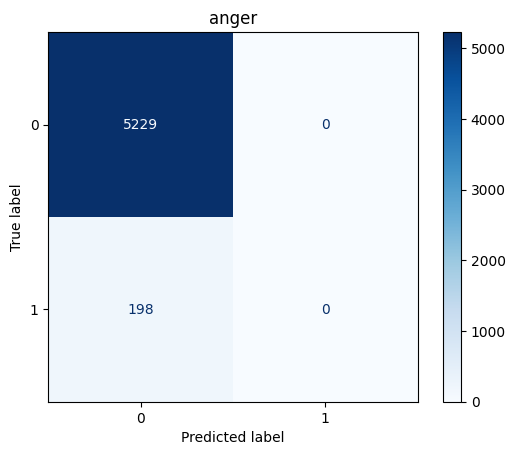

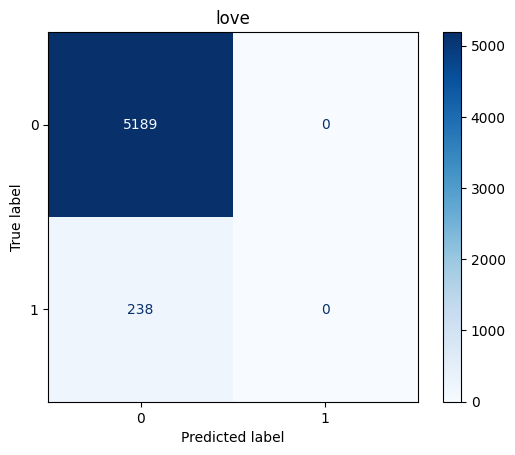

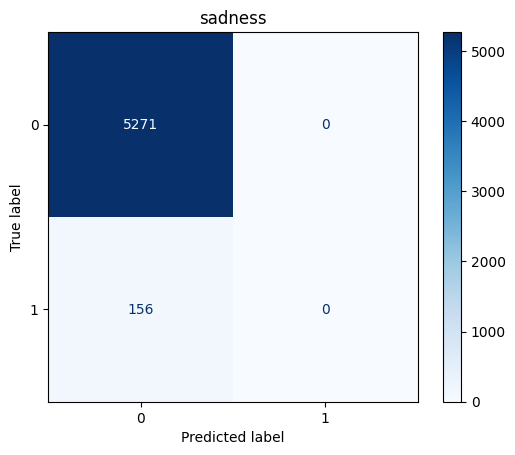

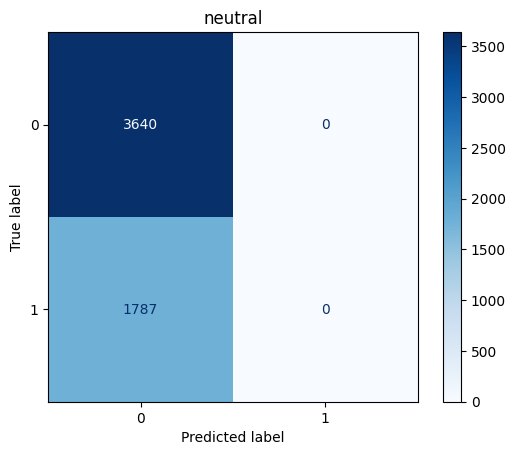

In [37]:
RF_metrics = results_display(y_test_multi, y_pred_multi)

# Logistic Regression

Fit and Validate

In [38]:
# Logistic Regression

best_f1 = -1
best_c = 0
best_LR = None

for c in [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]:
    print(f"Training with C =  {c}")
    val_pred = []
    cur_model = []
    for i in range(len(label_columns)):
        y_binary = y_train_multi[:, i]
        model = LogisticRegression(max_iter=1000, solver="saga", random_state=42, C=c)
        model.fit(X, y_binary)
        pred = model.predict(X_val)
        val_pred.append(pred)
        cur_model.append(model)
    val_pred = np.array(val_pred).T
    f1 = f1_score(y_val_multi, val_pred, average="macro")
    print(f"F1 score: {f1}")
    if f1 > best_f1:
        best_c = c
        best_f1 = f1
        best_LR = cur_model
print(f"Best C for model: {best_c}")

Training with C =  0.01
F1 score: 0.08318046276274005
Training with C =  0.05
F1 score: 0.16145471291357988
Training with C =  0.1
F1 score: 0.21758439193446336
Training with C =  0.5
F1 score: 0.31171000743376653
Training with C =  1.0
F1 score: 0.33794225393580163
Training with C =  5.0
F1 score: 0.3745519283883939
Training with C =  10.0
F1 score: 0.37142048611867456
Best C for model: 5.0


Predict on test data

In [39]:
predictions = []
for model in best_LR:
    pred = model.predict(X_test)
    predictions.append(pred)
y_pred_multi = np.array(predictions).T

Results

Accuracy: 0.9635552396746426
F1 score: 0.3546640956249523
                precision    recall  f1-score   support

    admiration       0.63      0.48      0.55       504
     amusement       0.77      0.69      0.72       264
         anger       0.49      0.25      0.33       198
     annoyance       0.35      0.14      0.20       320
      approval       0.36      0.16      0.22       351
        caring       0.31      0.13      0.19       135
     confusion       0.30      0.10      0.16       153
     curiosity       0.32      0.10      0.15       284
        desire       0.55      0.20      0.30        83
disappointment       0.33      0.13      0.18       151
   disapproval       0.24      0.09      0.13       267
       disgust       0.65      0.30      0.41       123
 embarrassment       0.40      0.11      0.17        37
    excitement       0.48      0.20      0.29       103
          fear       0.75      0.46      0.57        78
     gratitude       0.94      0.88      0.91

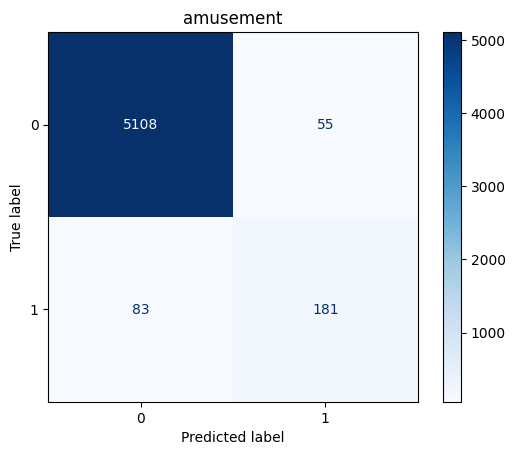

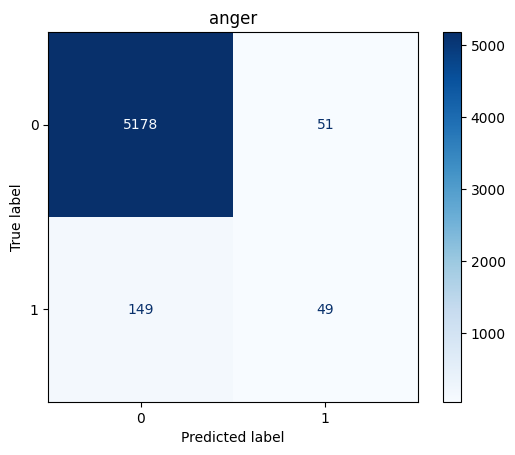

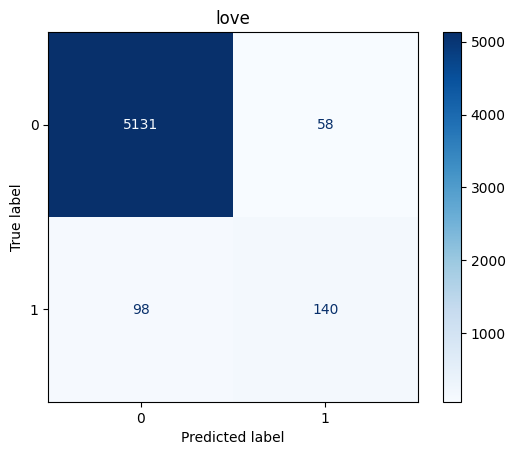

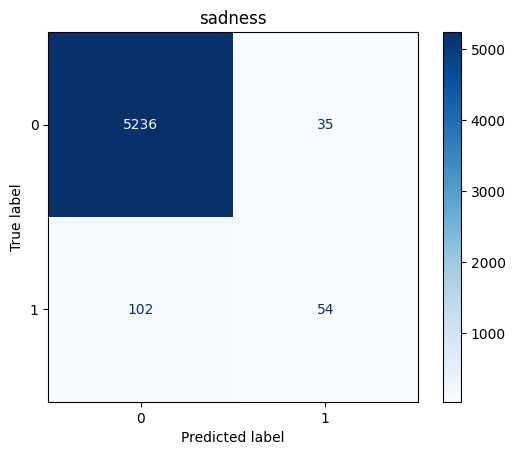

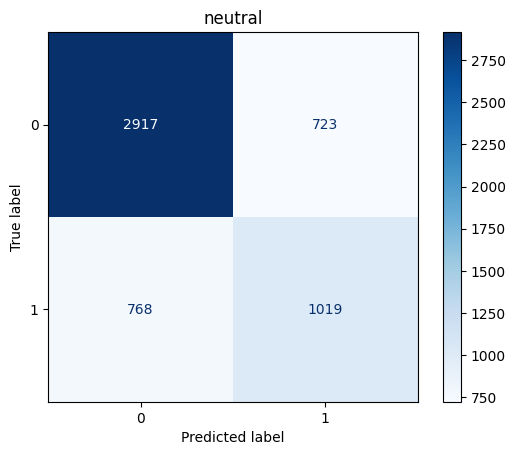

In [40]:
LR_metrics = results_display(y_test_multi, y_pred_multi)

# Bernoulli Naive Bayes

Fit and Validate

In [41]:
# Bernoulli Naive Bayes

best_f1 = -1
best_alpha = 0
best_Ber = None

for alpha in [0.1, 0.5, 1.0, 2.0, 5.0]:
    print(f"Training with alpha =  {alpha}")
    val_pred = []
    cur_model = []
    for i in range(len(label_columns)):
        y_binary = y_train_multi[:, i]
        model = BernoulliNB(alpha=alpha)
        model.fit(X, y_binary)
        pred = model.predict(X_val)
        val_pred.append(pred)
        cur_model.append(model)
    val_pred = np.array(val_pred).T
    f1 = f1_score(y_val_multi, val_pred, average="macro")
    print(f"F1 score: {f1}")
    if f1 > best_f1:
        best_alpha = alpha
        best_f1 = f1
        best_Ber = cur_model
print(f"Best alpha for model: {best_alpha}")

Training with alpha =  0.1
F1 score: 0.2502077029633194
Training with alpha =  0.5
F1 score: 0.17105005027837678
Training with alpha =  1.0
F1 score: 0.10781423426421957
Training with alpha =  2.0
F1 score: 0.04355696127565498
Training with alpha =  5.0
F1 score: 0.00962889292211303
Best alpha for model: 0.1


Predict on test data

In [42]:
predictions = []
for model in best_Ber:
    pred = model.predict(X_test)
    predictions.append(pred)
y_pred_multi = np.array(predictions).T

Results

Accuracy: 0.960764958277396
F1 score: 0.24995787585126786
                precision    recall  f1-score   support

    admiration       0.65      0.40      0.50       504
     amusement       0.77      0.43      0.55       264
         anger       0.38      0.15      0.21       198
     annoyance       0.31      0.12      0.18       320
      approval       0.33      0.11      0.16       351
        caring       0.21      0.13      0.16       135
     confusion       0.34      0.10      0.15       153
     curiosity       0.30      0.07      0.11       284
        desire       0.33      0.07      0.12        83
disappointment       0.18      0.05      0.07       151
   disapproval       0.21      0.07      0.11       267
       disgust       0.58      0.21      0.31       123
 embarrassment       0.00      0.00      0.00        37
    excitement       0.32      0.15      0.20       103
          fear       0.77      0.26      0.38        78
     gratitude       0.87      0.77      0.82

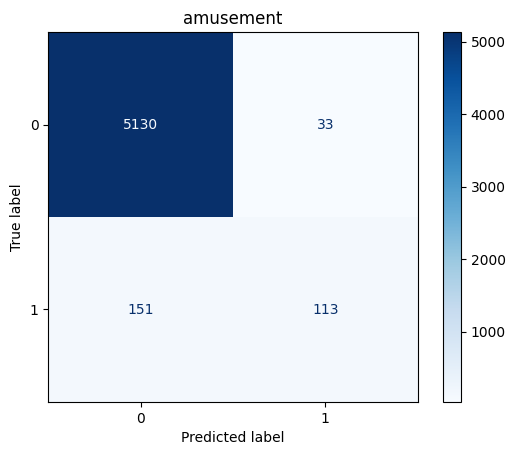

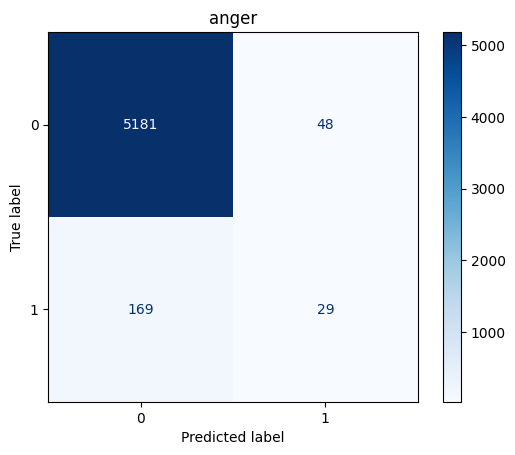

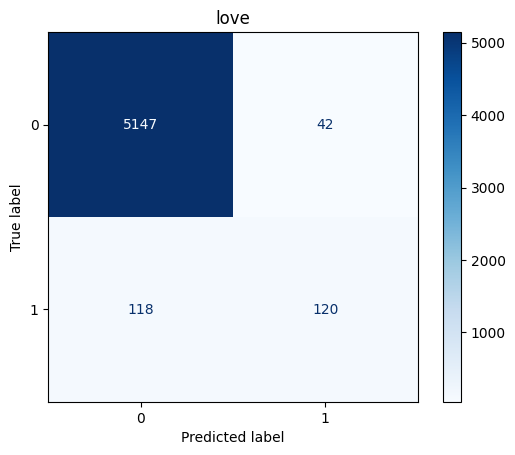

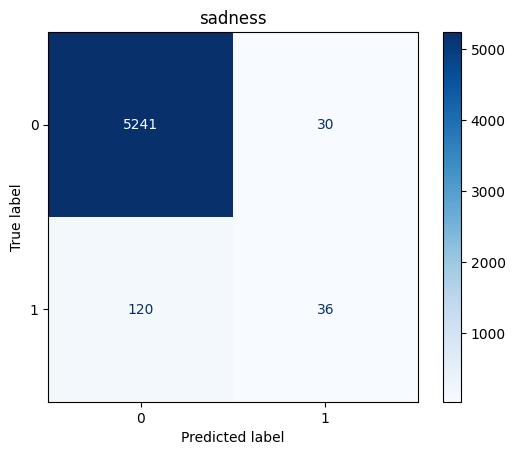

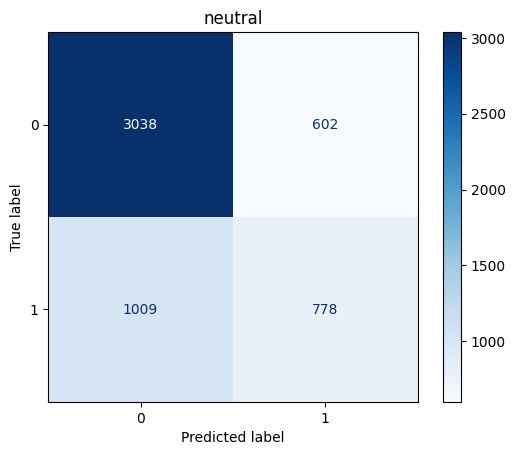

In [43]:
NB_metrics = results_display(y_test_multi, y_pred_multi)

# Model comparison

In [44]:
comparison = {"Decision Tree": DT_metrics, "Random Forest": RF_metrics, "Logistic Regression": LR_metrics, "Bernoulli Naive Bayes": NB_metrics}

In [45]:
comparison_df = pd.DataFrame(comparison).T
comparison_df

,Accuracy:,F1 Score
Decision Tree,0.963503,0.353347
Random Forest,0.958363,0.000404
Logistic Regression,0.963555,0.354664
Bernoulli Naive Bayes,0.960765,0.249958


# Model output

In [46]:
import joblib
joblib.dump(best_DT, "m_dt.pkl")
joblib.dump(best_RF, "m_rf.pkl")
joblib.dump(best_LR, "m_lr.pkl")
joblib.dump(best_Ber, "m_ber.pkl")

['m_ber.pkl']